In [1]:
from sklearn import datasets
iris = datasets.load_iris()

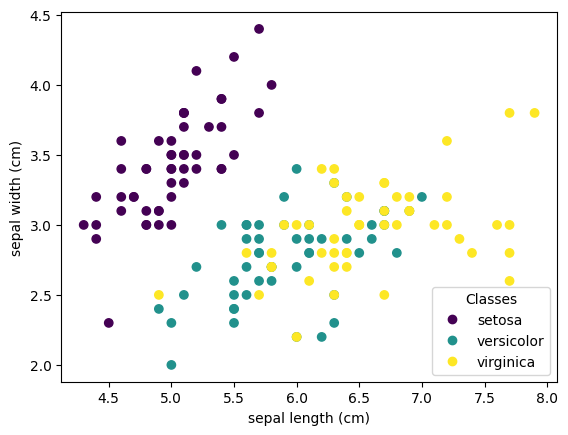

In [2]:
import matplotlib.pyplot as plt

_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target)
ax.set(xlabel=iris.feature_names[0], ylabel=iris.feature_names[1])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features for better distance calculation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2. Train KNN Classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

# 3. Evaluate
y_pred = knn_clf.predict(X_test_scaled)
print("=== KNN Classification ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

=== KNN Classification ===
Accuracy: 0.933


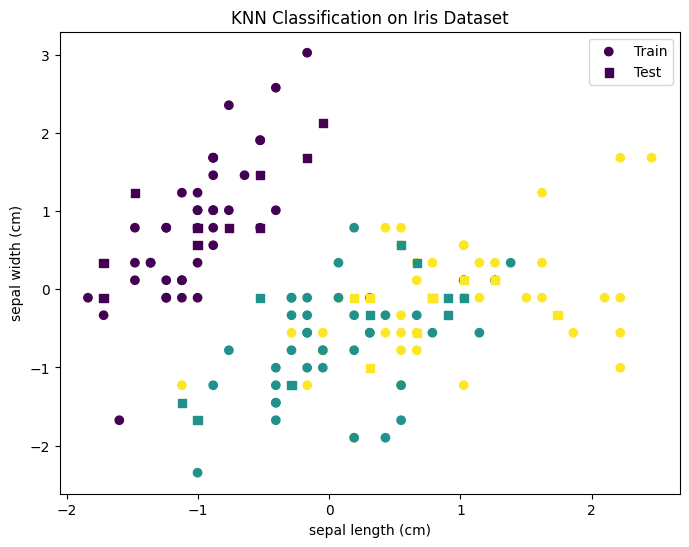

In [4]:
#plot the training points and the test points
plt.figure(figsize=(8, 6))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, marker='o', label='Train')
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, marker='s', label='Test')
plt.title('KNN Classification on Iris Dataset')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend()
plt.show()

Let's use KNN for Regression purpose


=== KNN Regression ===
Mean Squared Error: 239.81
R^2 Score: 0.871


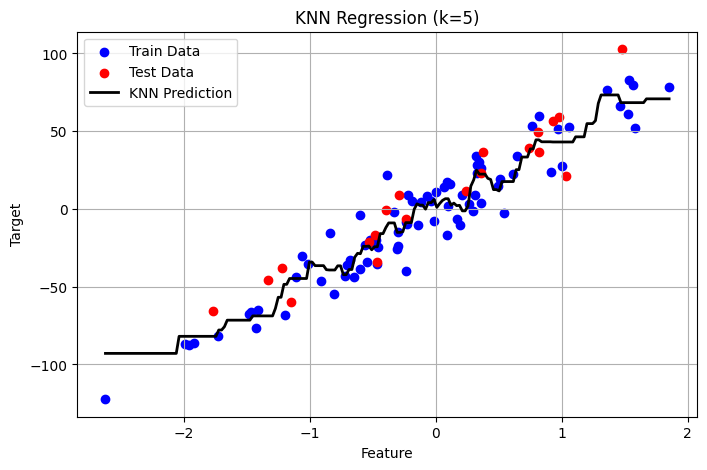

In [ ]:
# 1. Create a simple 1-D regression dataset
X_reg, y_reg = make_regression(
    n_samples=100, n_features=1, noise=15, random_state=42)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# 2. KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r, y_train_r)

# 3. Predictions & Metrics
y_pred_r = knn_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
r2  = r2_score(y_test_r, y_pred_r)

print("\n=== KNN Regression ===")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.3f}")

# 4. Visualization of regression fit
# Sort for a smooth curve
X_curve = np.linspace(X_reg.min(), X_reg.max(), 200).reshape(-1, 1)
y_curve = knn_reg.predict(X_curve)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_r, y_train_r, color="blue", label="Train Data")
plt.scatter(X_test_r, y_test_r, color="red", label="Test Data")
plt.plot(X_curve, y_curve, color="black", linewidth=2, label="KNN Prediction")
plt.title("KNN Regression (k=5)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.grid(True)
plt.show()